# Multiple Linear Regression on Student Performance Dataset

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

Load Dataset
I used the Student Performance dataset obtained from the UCI Machine Learning Repository.
This dataset contains information about students’ academic performance in secondary education.

The target variable selected is G3, which represents the final grade of students.

The predictor variables used are:

G1 (first period grade)
G2 (second period grade)
studytime
failures
absences

These predictors were chosen because they directly influence student performance.

In [2]:
df = pd.read_csv("student-mat.csv", sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Data Info

The dataset contained categorical variables such as school, sex, and address. Since machine learning models require numerical input, categorical variables were converted into numerical values using one-hot encoding.

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


Preprocessing

Data preprocessing was performed to prepare the dataset for regression modeling.

Missing Values

The dataset was checked for missing values using:
No missing values were found in the dataset.

In [4]:
df.isnull().sum()

df = pd.get_dummies(df, drop_first=True)

X = df[['G1', 'G2', 'studytime', 'failures', 'absences']]
y = df['G3']

Heatmap


Correlation Analysis

A correlation heatmap was created to visualize relationships between variables.

Observations from Heatmap
G1 and G2 showed a strong positive correlation with G3.
Failures showed a negative correlation with final grades.
Absences showed a weak negative relationship with final grades.

The heatmap helped identify variables that are useful predictors for the regression model.

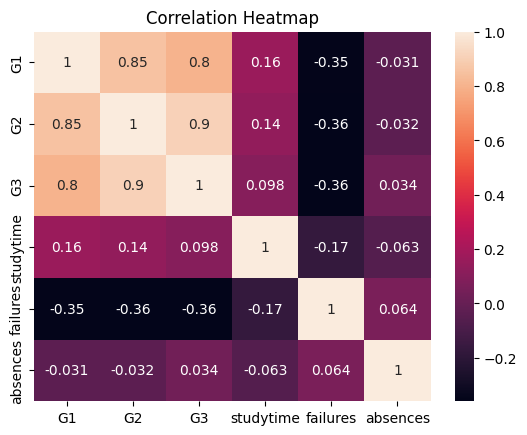

In [5]:
sns.heatmap(df[['G1','G2','G3','studytime','failures','absences']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Visualizations

Visualization 1: G1 vs G3 Scatter Plot

This scatter plot shows the relationship between the first period grade and the final grade.

Observation:
Students with higher first period grades generally achieved higher final grades.

Visualization 2: Study Time vs G3 Boxplot

This boxplot shows how study time affects final grades.

Observation:
Students who study more hours tend to achieve better final grades.

Visualization 3: Absences vs G3 Scatter Plot

This scatter plot shows the relationship between absences and final grades.

Observation:
Students with many absences tend to have slightly lower final grades.

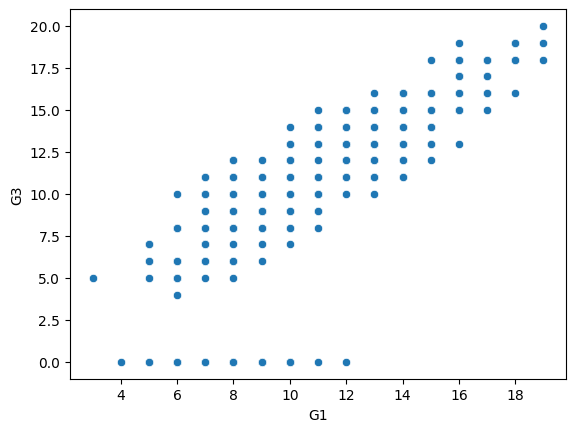

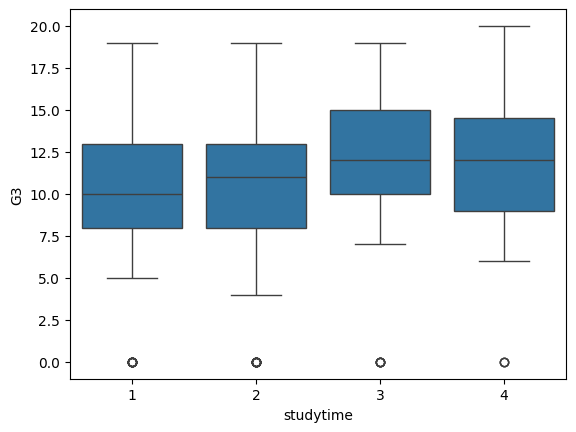

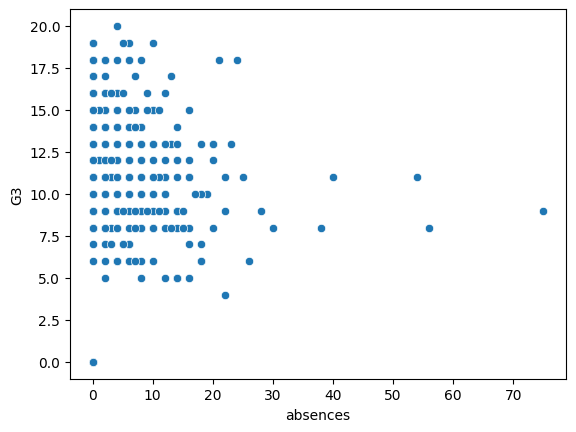

In [6]:
sns.scatterplot(x='G1', y='G3', data=df)
plt.show()

sns.boxplot(x='studytime', y='G3', data=df)
plt.show()

sns.scatterplot(x='absences', y='G3', data=df)
plt.show()

Train - Test Split



The dataset was divided into training and testing sets using an 80:20 ratio.

This is important because:

The training set is used to train the model.
The testing set evaluates how well the model performs on unseen data.
It helps reduce overfitting.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Model
The Multiple Linear Regression model was built using Scikit-learn.

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

model.intercept_, model.coef_

(np.float64(-1.6213124035190898),
 array([ 0.14446336,  0.97961532, -0.07123057, -0.45581289,  0.0392449 ]))

Predictions

In [9]:
y_pred = model.predict(X_test)

Evaluation

In [10]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae, rmse

(1.339415908267092, np.float64(2.1134103274129243))

Actual vs Predicted
A scatter plot comparing actual and predicted grades was generated.

Observation:
Most predicted values were close to the actual values, indicating that the model performed reasonably well.

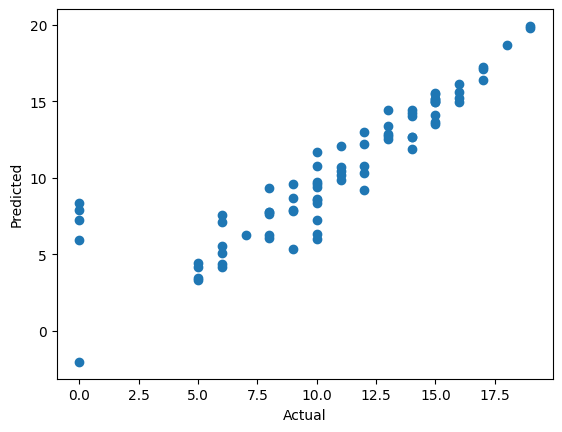

In [11]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

Conclusion

A Multiple Linear Regression model was successfully developed using the Student Performance dataset.

The selected predictors showed meaningful relationships with students’ final grades. The model performed reasonably well based on the evaluation metrics and visual analysis.

This assignment improved understanding of data preprocessing, exploratory data analysis, regression modeling, and model evaluation using Python and Scikit-learn.